## **Seaborn Exercise set**

## **Exercise 01**
---

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#load dataset 
penguine = sns.load_dataset("penguins")

penguine.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [63]:
penguine.value_counts("species")

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [64]:
#drop missing values
penguine.dropna(inplace=True)
penguine.value_counts("species")

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

## 1. Pair plot of the data

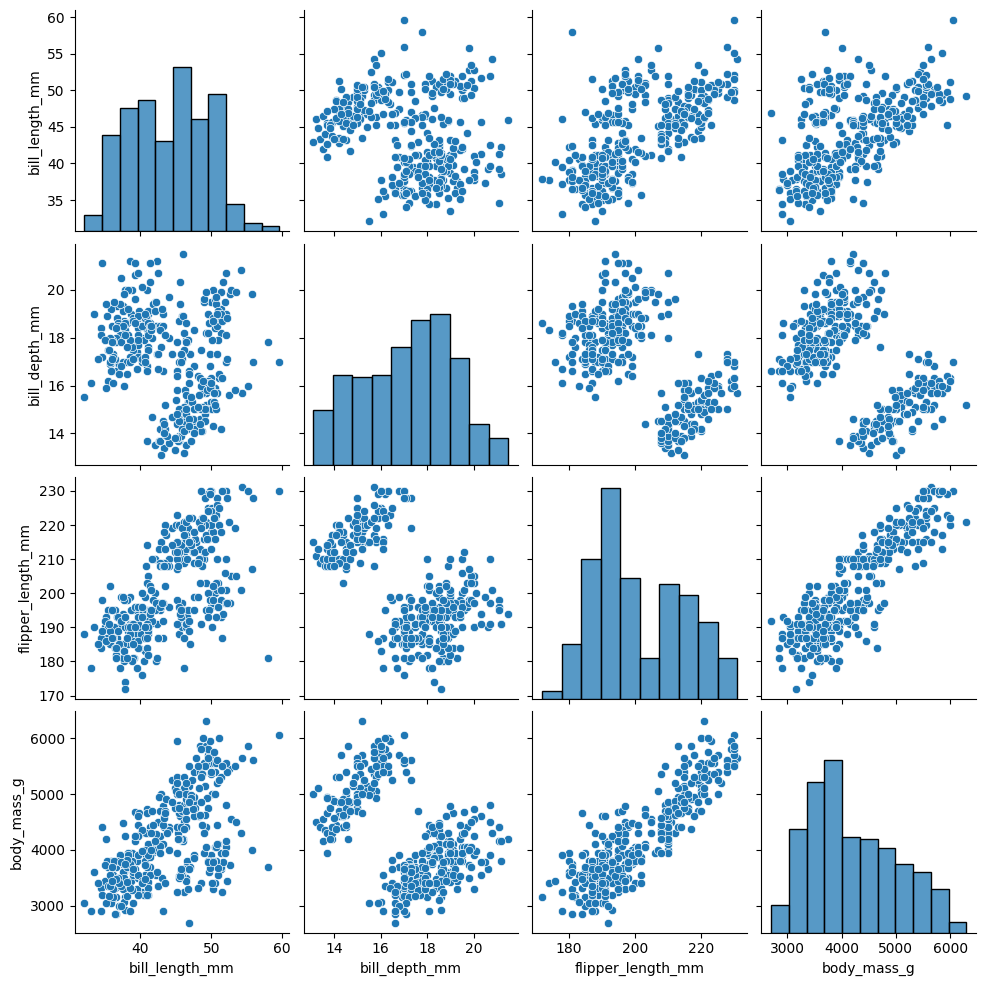

In [65]:
sns.pairplot(penguine)

### **Answer:** There is a strong positive correlation between flipper length of the penguines and body mass of the penguines. The largers penguines have longer flippers 
___

## Extra: Correlation matrix 

<Axes: >

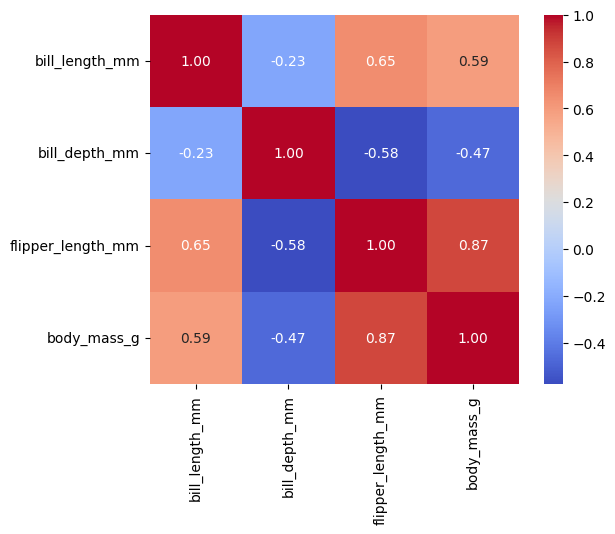

In [66]:
corr_matrix = penguine.select_dtypes(include="number").corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)

## 2. Pair plot with Hue (island)

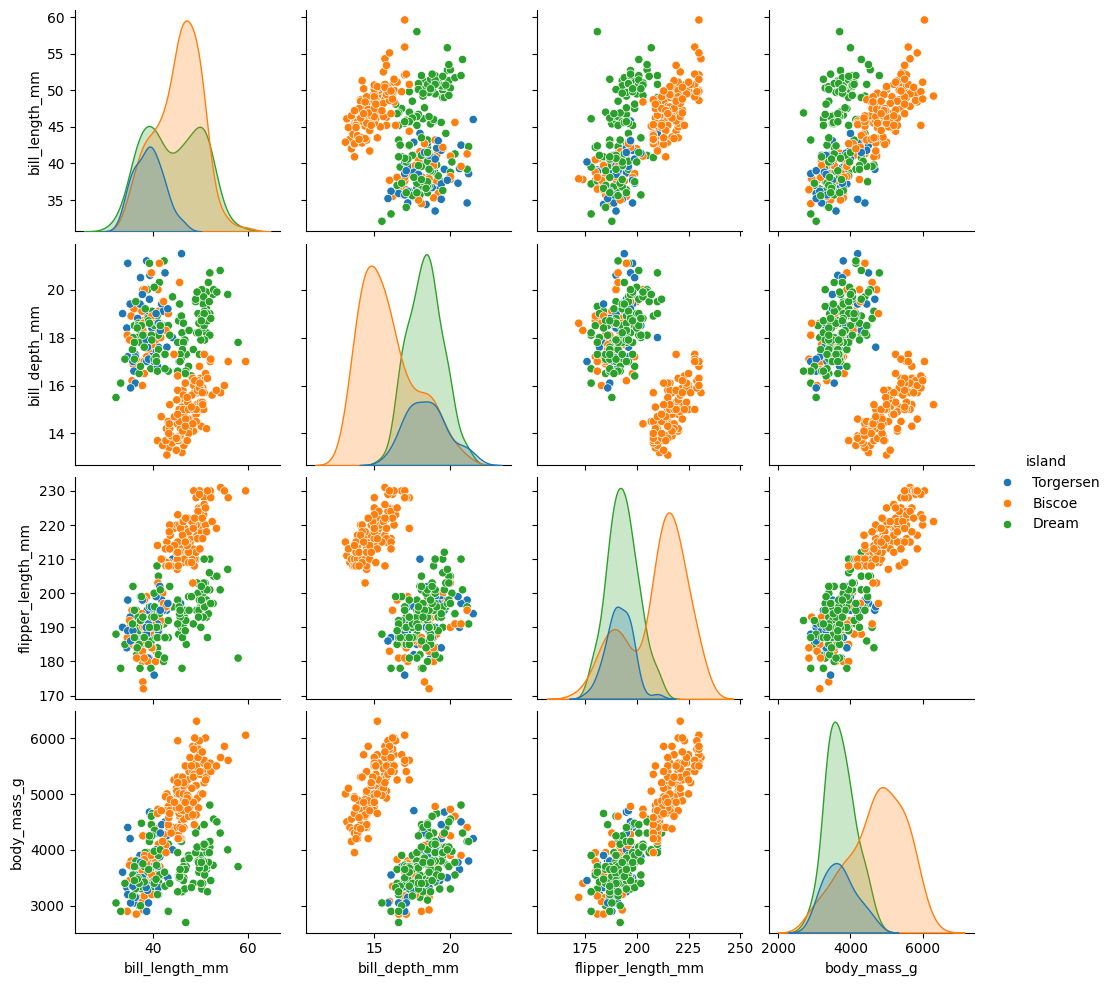

In [67]:
sns.pairplot(penguine, hue='island')

### **Answer:** The three islands have noticeably different penguine populations. Bisco island pengines tend to have longer flippers and higher body mass. Dream and Torgersen island penguines overlap more in most measurements.
___

## 3. Penguin Counts per Island

In [68]:
island_counts = penguine['island'].value_counts()

island_counts

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

### **Asnwer:** Torgersen has considerably fewer penguins than Biscoe and Dream. This imbalance means Torgersen is underrepresented in the dataset
___

## Extra : bar plot

C:\Users\savin\AppData\Local\Temp\ipykernel_24168\4182365170.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=penguine, x='island', palette='Set2')


<Axes: xlabel='island', ylabel='count'>

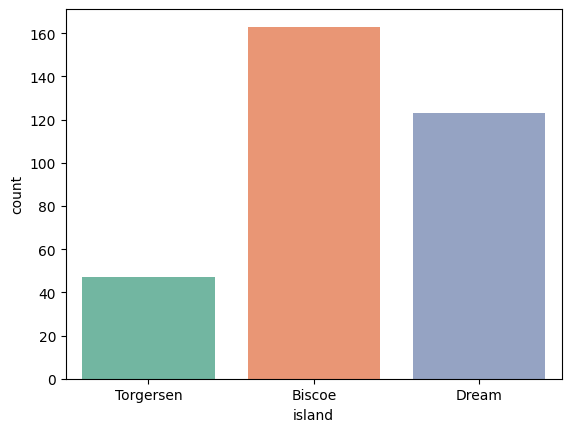

In [69]:
sns.countplot(data=penguine, x='island', palette='Set2')

## 4. Pair Plot with Hue (Species)

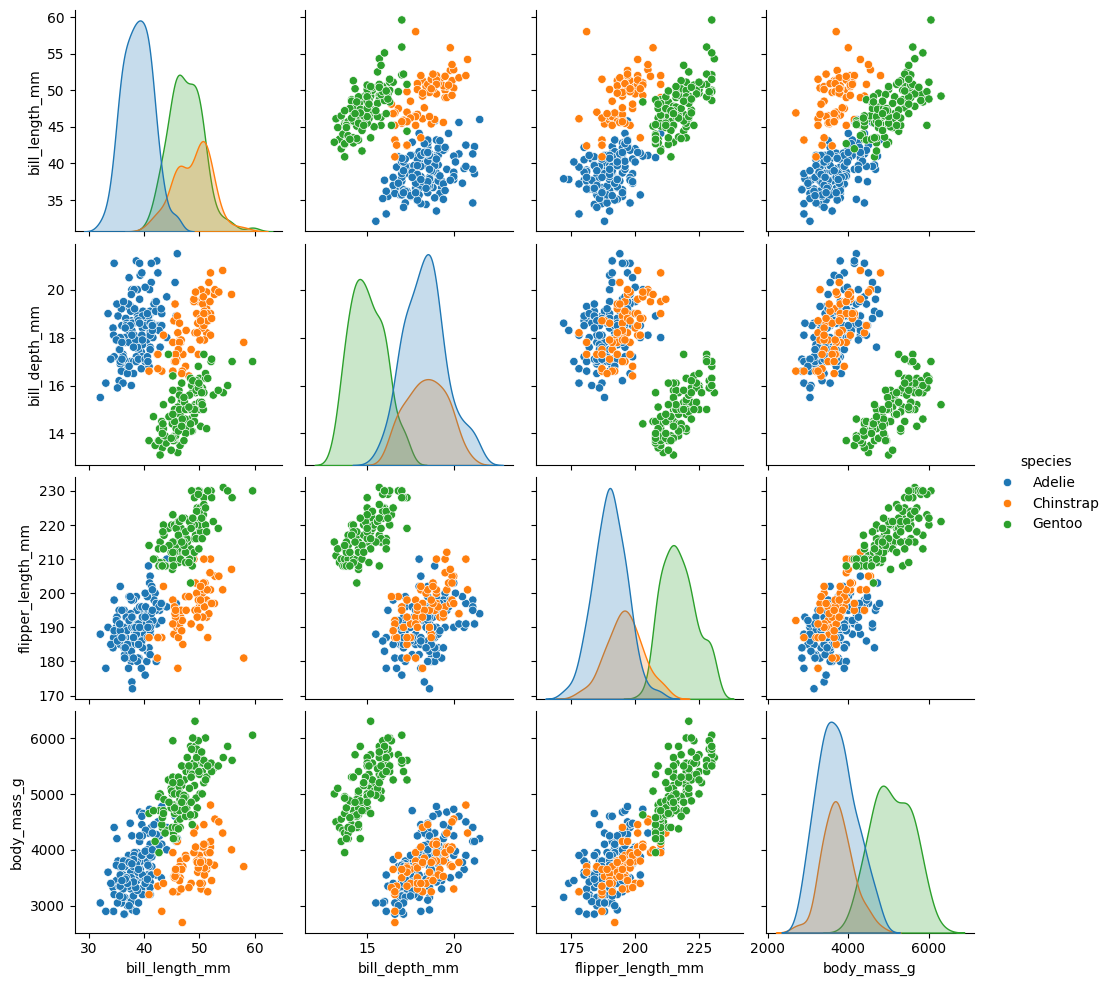

In [70]:
sns.pairplot(penguine, hue='species')

### **Asnwer:** Species as hue produces much cleaner and better separated clusters than island. The three species have lot of physical differences across nearly all variable combinations. where as island hue shows considerable overlap.
___

## Extra: pair plot (sex)

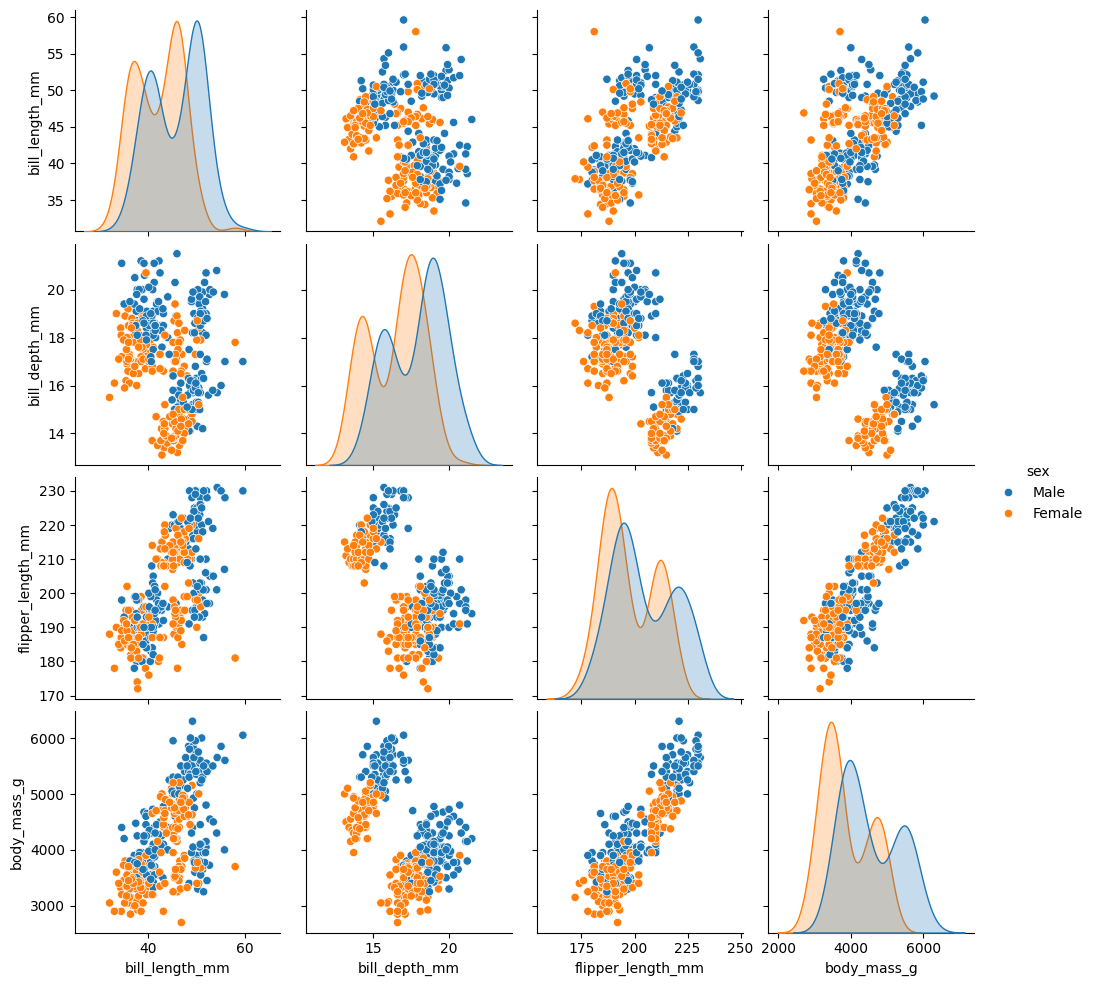

In [71]:
sns.pairplot(penguine, hue='sex')

### **Asnwer:** Sex has moderate effect. Male penguins are consistently larger (higher body mass, longer flippers, longer bills) than females across all species. But data still overlap considerably. 
___

## 5. Scatter Plot: Bill Length vs Flipper Length

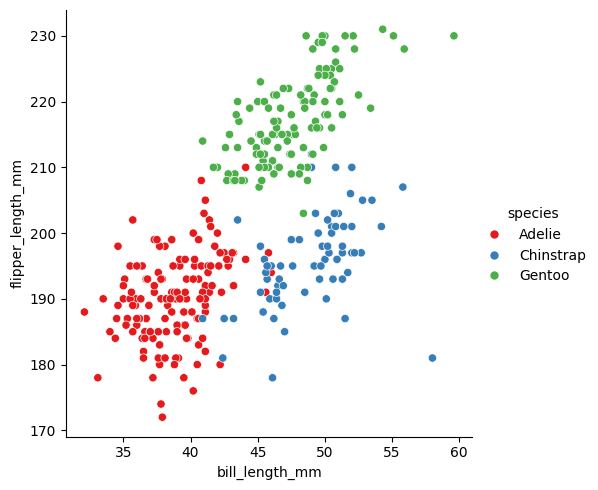

In [72]:
# hue as species
sns.relplot(data=penguine, x='bill_length_mm', y='flipper_length_mm',hue='species', palette='Set1')

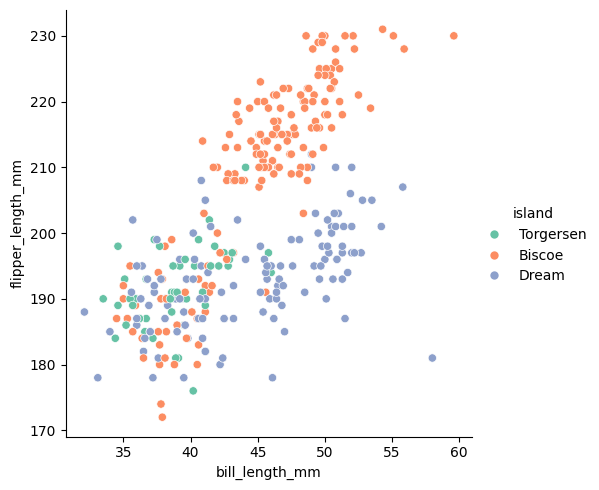

In [73]:
# hue as Island
sns.relplot(data=penguine, x='bill_length_mm', y='flipper_length_mm',hue='island', palette='Set2')

### **Answer:** Species gives more distinct separation. The three species form non overlapping clusters in both bill length and flipper length. Island as hue produces much more overlap. This confirms that species is more informative grouping variable for physical measurements.
___

## 06. Box plots 

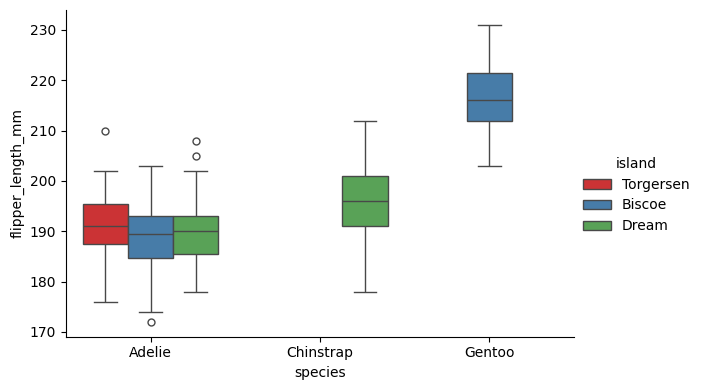

In [74]:
# Inspecting flipper length
sns.catplot(data=penguine, kind='box', x='species', y='flipper_length_mm',
            hue='island', palette='Set1', height=4, aspect=1.5)

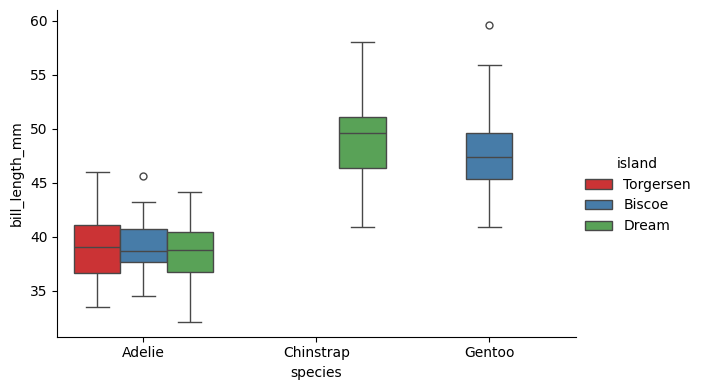

In [75]:
# Inspecting bill length
sns.catplot(data=penguine, kind='box', x='species', y='bill_length_mm',
            hue='island', palette='Set1', height=4, aspect=1.5)

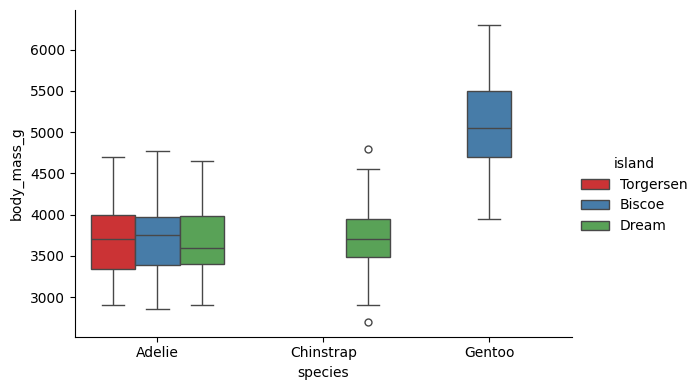

In [76]:
# Inspecting body mass
sns.catplot(data=penguine, kind='box', x='species', y='body_mass_g',
            hue='island', palette='Set1', height=4, aspect=1.5)

## **Answer:** 
### **Gentoo penguins** are the largest species. They have the longest flippers and highest body mass by a wide margin. They are only in Biscoe island 
### **Chinstrap penguins** have the longest bills on average but body mass and flipper length are in mid range. They are only in Dream island
### **Adelie penguins** are the only species present on all three islands and are the smallest overall. They have the shortest bills and shortest flippers.
___

## **Exercise 02**
---

In [77]:
#load dataset
df = sns.load_dataset("mpg")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [78]:
df.shape

(398, 9)

## 01. Clean dataset

In [79]:
df.isna().sum() 

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [80]:
df = df.dropna()

In [81]:
# Formula: liters_per_100km = 235.214583 / mpg
df['liters_per_100km'] = 235.214583 / df['mpg']

# Remove the original mpg column
df = df.drop(columns=['mpg'])

# Remove the 'name' column
df = df.drop(columns=['name'])

df.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,liters_per_100km
0,8,307.0,130.0,3504,12.0,70,usa,13.067477
1,8,350.0,165.0,3693,11.5,70,usa,15.680972
2,8,318.0,150.0,3436,11.0,70,usa,13.067477
3,8,304.0,150.0,3433,12.0,70,usa,14.700911
4,8,302.0,140.0,3449,10.5,70,usa,13.836152


## 02. Correlation matrix and heatmap

In [82]:
df_numeric = df.select_dtypes(include='number')
corr_matrix = df_numeric.corr()

corr_matrix

,cylinders,displacement,horsepower,weight,acceleration,model_year,liters_per_100km
cylinders,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,0.839385
displacement,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,0.866050
horsepower,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,0.854809
weight,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,0.885056
acceleration,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,-0.456338
model_year,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,-0.558255
liters_per_100km,0.839385,0.866050,0.854809,0.885056,-0.456338,-0.558255,1.000000


In [83]:
# remove two columns with low correlation
df = df.drop(columns=['acceleration', 'model_year'])

### **Answer:** 'acceleration' and 'model_year' columns have a low correlation. **acceleration** Has relatively low correlations with consumption related variables. It does not strongly predict fuel efficiency or other technical characteristics. **model_year** represents a time dimension rather than a physical car property. The newer cars tend to be more efficient but it does not directly reflect the mechanical characteristics of the car

In [84]:
df_numeric = df.select_dtypes(include='number')
corr_matrix = df_numeric.corr()

corr_matrix

,cylinders,displacement,horsepower,weight,liters_per_100km
cylinders,1.000000,0.950823,0.842983,0.897527,0.839385
displacement,0.950823,1.000000,0.897257,0.932994,0.866050
horsepower,0.842983,0.897257,1.000000,0.864538,0.854809
weight,0.897527,0.932994,0.864538,1.000000,0.885056
liters_per_100km,0.839385,0.866050,0.854809,0.885056,1.000000


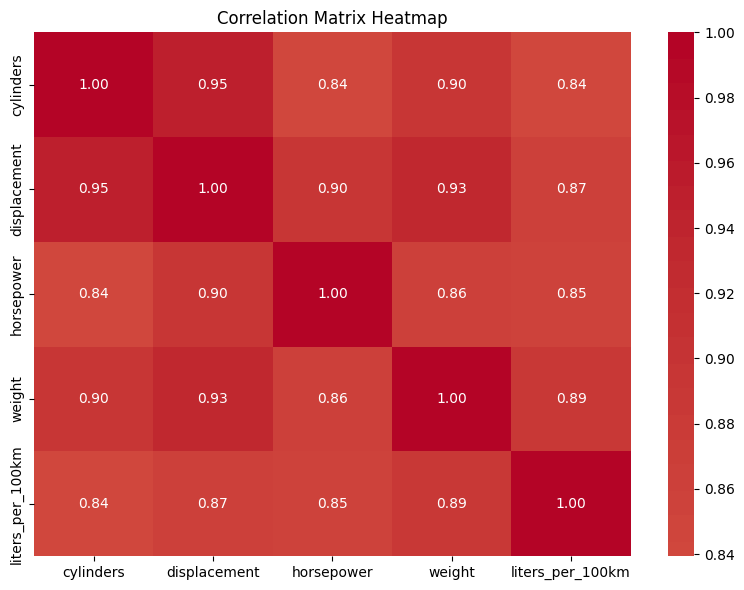

In [85]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

## 03. Best efficiency indicator

**displacement** (engine size) is the best single indicator of car efficiency because:
- It has one of the strongest correlations with **liters_per_100km** (fuel consumption).
- It also correlates well with **weight** and **horsepower**. 
- it captures the overall "size" and power profile of the car.
- **horsepower** reflects engine output. But it can vary significantly by tuning. two cars with the same displacement can have very different horsepower.
- **displacement** is the fundamental mechanical property. because a bigger engine burns more fuel regardless of tuning.


In [86]:
# Remove cylinders and horsepower
df = df.drop(columns=['cylinders', 'horsepower'])

df.head()

,displacement,weight,origin,liters_per_100km
0,307.0,3504,usa,13.067477
1,350.0,3693,usa,15.680972
2,318.0,3436,usa,13.067477
3,304.0,3433,usa,14.700911
4,302.0,3449,usa,13.836152


## 04. Pair plot by origin

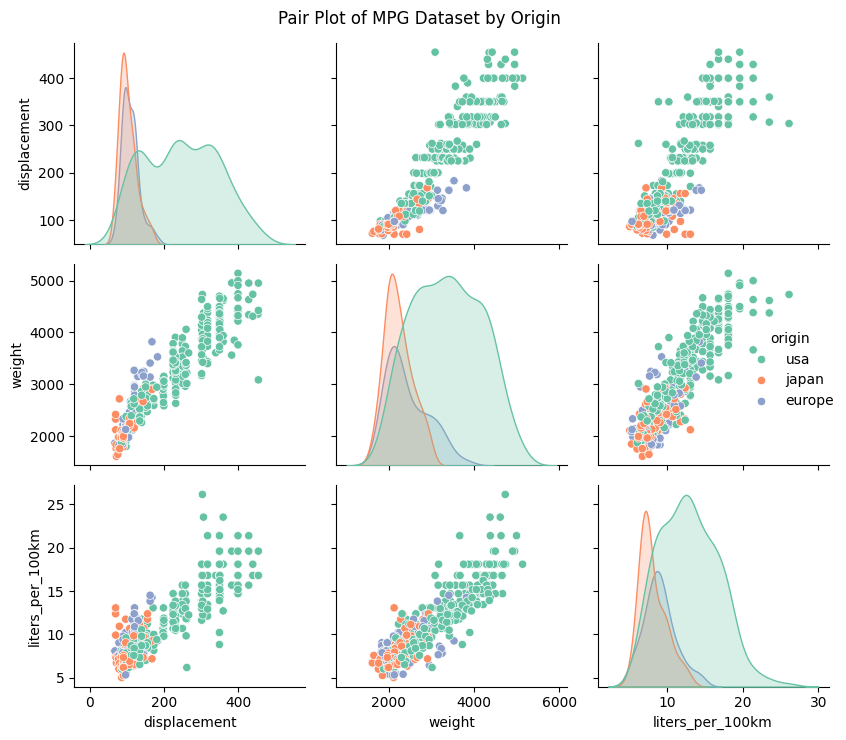

In [87]:
sns.pairplot(df, hue='origin', palette='Set2')
plt.suptitle('Pair Plot of MPG Dataset by Origin')
plt.tight_layout()
plt.show()

### Which origin has the highest consumption?
### **Answer:** USA cars tend to have the highest fuel consumption (L/100km), driven by larger engines and heavier vehicles.

C:\Users\savin\AppData\Local\Temp\ipykernel_24168\1833355286.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='origin', y='liters_per_100km', palette='Set2',)


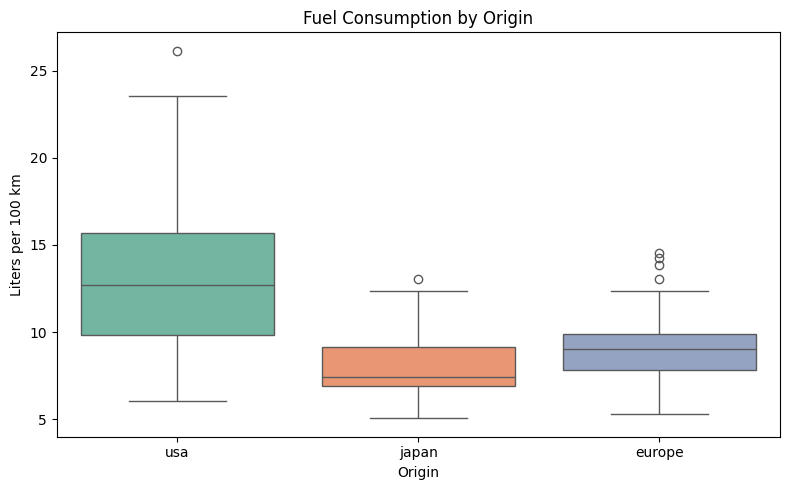

In [88]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='origin', y='liters_per_100km', palette='Set2',)
plt.title('Fuel Consumption by Origin')
plt.xlabel('Origin')
plt.ylabel('Liters per 100 km')
plt.tight_layout()
plt.show()

### Which origin has the lowest consumption?
### **Answer:** Japan shows the lowest fuel consumption with smaller and more efficient engines

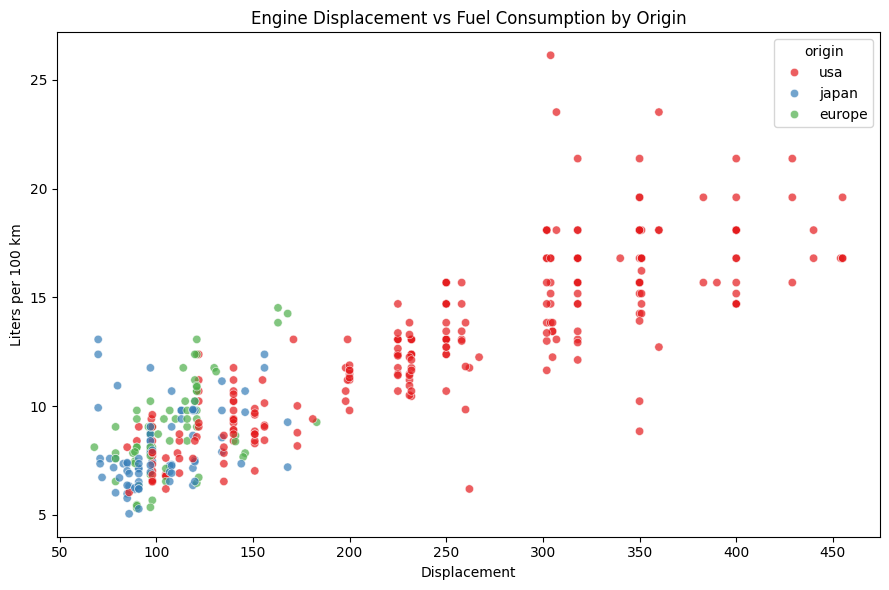

In [89]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='displacement', y='liters_per_100km', hue='origin', alpha=0.7, palette='Set1')
plt.title('Engine Displacement vs Fuel Consumption by Origin')
plt.xlabel('Displacement')
plt.ylabel('Liters per 100 km')
plt.tight_layout()
plt.show()

C:\Users\savin\AppData\Local\Temp\ipykernel_24168\362840867.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='origin', y='weight', palette='Set3')


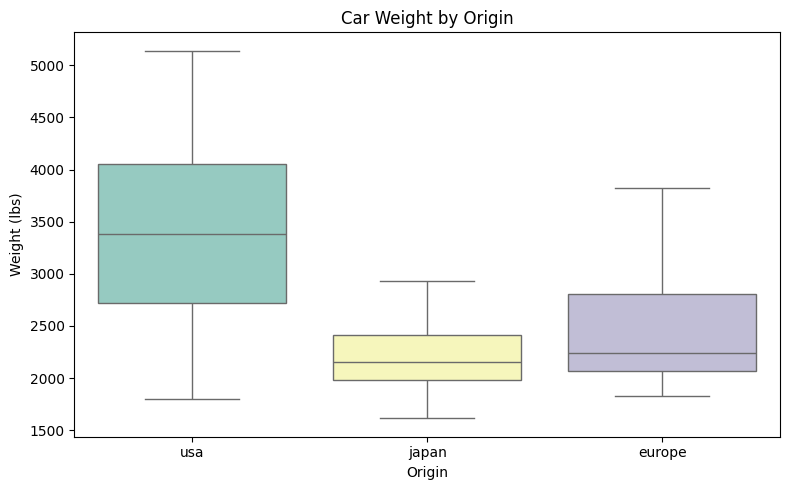

In [90]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='origin', y='weight', palette='Set3')
plt.title('Car Weight by Origin')
plt.xlabel('Origin')
plt.ylabel('Weight (lbs)')
plt.tight_layout()
plt.show()

In [91]:
df.groupby('origin')['weight'].mean().sort_values(ascending=False)

origin
usa       3372.489796
europe    2433.470588
japan     2221.227848
Name: weight, dtype: float64

### What other features result in bigger or lower consumption?
- **Higher weight** means higher consumption (heavier cars need more energy to move).
- **Larger displacement** means higher consumption (bigger engines burn more fuel).
- Cars from **Europe and Japan** tend to be lighter and have smaller engines. This result in better fuel economy.
___

## **Exercise 03**
---

In [92]:
# Load the dataset 
df = pd.read_csv('exerciseset3_datafiles/groceries.csv')

df.head()


,Month,Rice,Wheat,Barley,Corn,Peanuts,Sugar,Coconut-oil,Palm-oil,Sunflower-oil,Chicken,Beef,Pork,Fish,Tea,Coffee
0,Oct-90,0.28,0.11,0.09,0.10,2.12,0.0049,0.28,0.29,0.58,0.0236,0.0571,2.5051,6.35,1.60,1.24
1,Nov-90,0.27,0.11,0.09,0.10,2.11,0.0049,0.34,0.33,0.56,0.0236,0.0558,2.4414,6.46,1.58,1.22
2,Dec-90,0.26,0.11,0.09,0.10,2.00,0.0046,0.32,0.35,0.55,0.0231,0.0562,2.3479,6.50,1.52,1.24
3,Jan-91,0.30,0.11,0.09,0.11,1.85,0.0042,0.34,0.35,0.57,0.0231,0.0571,2.6495,6.34,1.55,1.16
4,Feb-91,0.33,0.11,0.09,0.11,1.79,0.0042,0.33,0.34,0.60,0.0238,0.0602,2.3517,6.41,1.48,1.14


## 01. Fill the missing data 

In [93]:
df.isna().sum()

Month              0
Rice               0
Wheat              0
Barley             0
Corn               0
Peanuts            0
Sugar              0
Coconut-oil        0
Palm-oil           0
Sunflower-oil    141
Chicken            0
Beef               0
Pork              39
Fish              39
Tea                0
Coffee             0
dtype: int64

In [94]:
# Fill missing values with column means
df.fillna({'Fish': df['Fish'].mean()}, inplace=True)
df.fillna({'Pork': df['Pork'].mean()}, inplace=True)
df.fillna({'Sunflower-oil': df['Sunflower-oil'].mean()}, inplace=True)

df.isna().sum() 

Month            0
Rice             0
Wheat            0
Barley           0
Corn             0
Peanuts          0
Sugar            0
Coconut-oil      0
Palm-oil         0
Sunflower-oil    0
Chicken          0
Beef             0
Pork             0
Fish             0
Tea              0
Coffee           0
dtype: int64

In [95]:
# Split Month column into Month and Year
months = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 
          'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

df[['Month_name', 'Year']] = df['Month'].str.split('-', expand=True)
df['Month'] = df['Month_name'].map(months)
df = df.drop('Month_name', axis=1)

# Adjust Year values to be in the correct century
# I get this code from AI. 
# It checks if the year is less than 50 and it assumes it's 2000s otherwise it's 1900s.
df['Year'] = df['Year'].apply(lambda x: '20' + x if int(x) < 50 else '19' + x)

df.head()

,Month,Rice,Wheat,Barley,Corn,Peanuts,Sugar,Coconut-oil,Palm-oil,Sunflower-oil,Chicken,Beef,Pork,Fish,Tea,Coffee,Year
0,10,0.28,0.11,0.09,0.10,2.12,0.0049,0.28,0.29,0.58,0.0236,0.0571,2.5051,6.35,1.60,1.24,1990
1,11,0.27,0.11,0.09,0.10,2.11,0.0049,0.34,0.33,0.56,0.0236,0.0558,2.4414,6.46,1.58,1.22,1990
2,12,0.26,0.11,0.09,0.10,2.00,0.0046,0.32,0.35,0.55,0.0231,0.0562,2.3479,6.50,1.52,1.24,1990
3,1,0.30,0.11,0.09,0.11,1.85,0.0042,0.34,0.35,0.57,0.0231,0.0571,2.6495,6.34,1.55,1.16,1991
4,2,0.33,0.11,0.09,0.11,1.79,0.0042,0.33,0.34,0.60,0.0238,0.0602,2.3517,6.41,1.48,1.14,1991


## 02. Create correlations matrix and heatmap

In [96]:
corr_matrix = df.select_dtypes(include='number').corr()
corr_matrix

,Month,Rice,Wheat,Barley,Corn,Peanuts,Sugar,Coconut-oil,Palm-oil,Sunflower-oil,Chicken,Beef,Pork,Fish,Tea,Coffee
Month,1.000000,-0.044979,-0.013236,-0.030244,-0.044408,-0.001781,0.003578,-0.040258,-0.046552,-0.005825,-0.015935,0.006254,-0.049440,-0.080344,-0.030672,-0.000688
Rice,-0.044979,1.000000,0.764992,0.725854,0.820150,0.696030,0.704375,0.646414,0.793909,-0.082812,0.652289,0.616056,0.348913,0.473308,0.643568,0.567478
Wheat,-0.013236,0.764992,1.000000,0.892162,0.890443,0.580613,0.640290,0.618246,0.822121,-0.063324,0.646178,0.528809,0.398452,0.407069,0.477763,0.547567
Barley,-0.030244,0.725854,0.892162,1.000000,0.907648,0.609116,0.620424,0.529652,0.792855,-0.025409,0.619077,0.432840,0.386439,0.296844,0.507331,0.448200
Corn,-0.044408,0.820150,0.890443,0.907648,1.000000,0.710431,0.755538,0.680974,0.837823,0.007242,0.678824,0.615079,0.479255,0.466458,0.631756,0.562999
Peanuts,-0.001781,0.696030,0.580613,0.609116,0.710431,1.000000,0.611945,0.603114,0.684083,-0.155459,0.498765,0.628254,0.439308,0.393605,0.549859,0.420156
Sugar,0.003578,0.704375,0.640290,0.620424,0.755538,0.611945,1.000000,0.691739,0.761629,-0.078173,0.564009,0.566042,0.376719,0.607986,0.673708,0.584662
Coconut-oil,-0.040258,0.646414,0.618246,0.529652,0.680974,0.603114,0.691739,1.000000,0.835128,0.007093,0.659971,0.662576,0.276655,0.608828,0.662326,0.612844
Palm-oil,-0.046552,0.793909,0.822121,0.792855,0.837823,0.684083,0.761629,0.835128,1.000000,-0.086490,0.645418,0.560498,0.278544,0.506403,0.620940,0.709686
Sunflower-oil,-0.005825,-0.082812,-0.063324,-0.025409,0.007242,-0.155459,-0.078173,0.007093,-0.086490,1.000000,0.042563,-0.172918,0.024800,-0.310311,0.005189,-0.095457


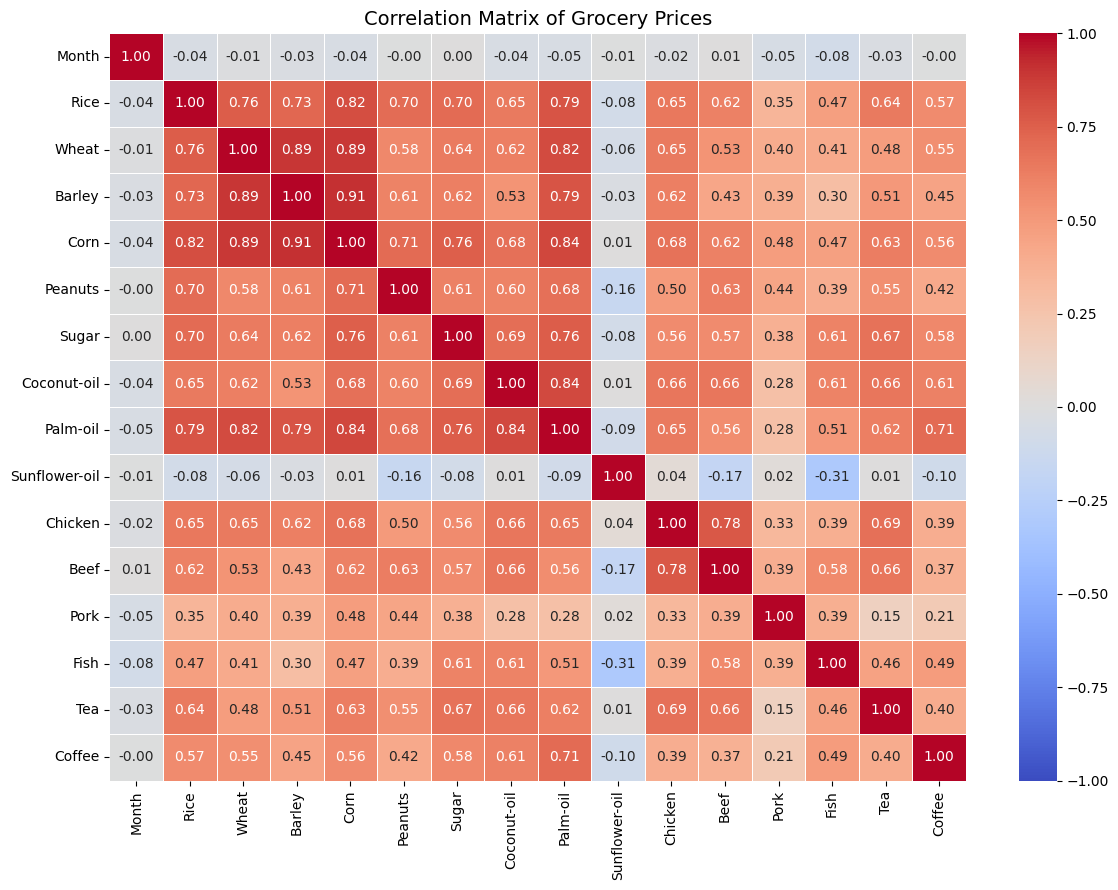

In [97]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Grocery Prices', fontsize=14)
plt.tight_layout()
plt.show()

### Which grocery stands out?
### **Answer:** Sunflower-oil 

### Which groceries seem to correlate to each other's prices? What do they have in common? 

### **Answer:**
### 
- **Grains** (Wheat, Barley, Corn, Rice) are the most tightly correlated cluster in the whole dataset. they're all globally traded bulk commodities.  they share the same demand like population, livestock feed..etc. a bad harvest in one region tends to shift buyers to the others 
- **Oils** (Palm oil, Coconut oil) are very strongly linked because they're direct substitutes in food manufacturing and industrial use. **Penuts** connects to this group because peanut oil competes in the same oil market. 
-  **Meats** (Beef, Chicken) are strongly linked because they compete for the same consumer food budget. Pork and fish is more loosely connected because pig farming and fish farming has a different regional market structures.
- **Sugar** correlates moderately with both the grains and the oils likely because it competes for the same agricultural land and shares the biofuel demand (I got this sugar information from AI)

## 03. Histograms: Fish, Coffee, and Tea

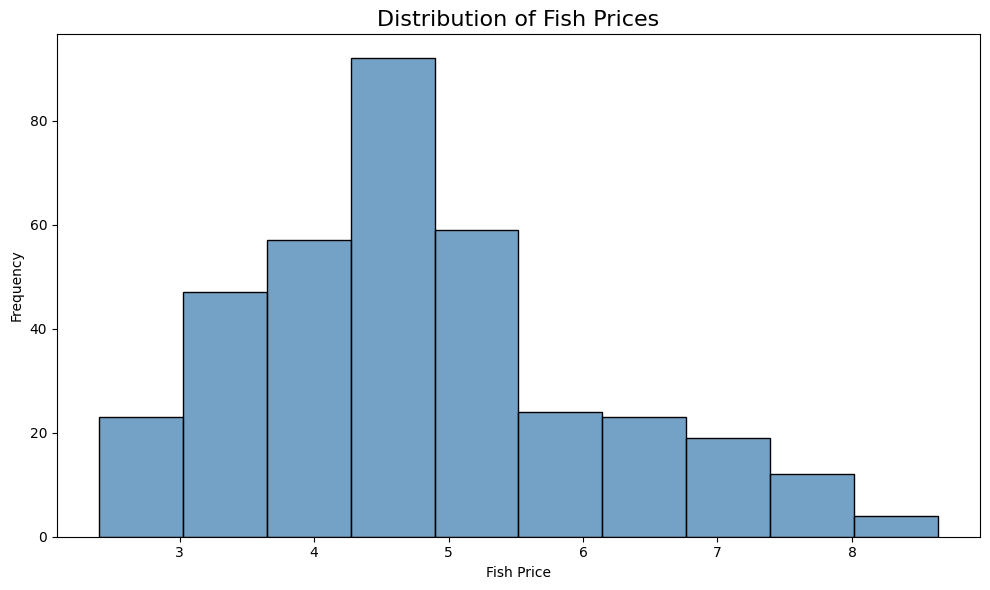

In [98]:
# histogram for Fish prices
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Fish', bins=10, color='steelblue', edgecolor='black')
plt.title('Distribution of Fish Prices', fontsize=16)
plt.xlabel('Fish Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Historically typical prices for **fish** is around 3$ - 6$

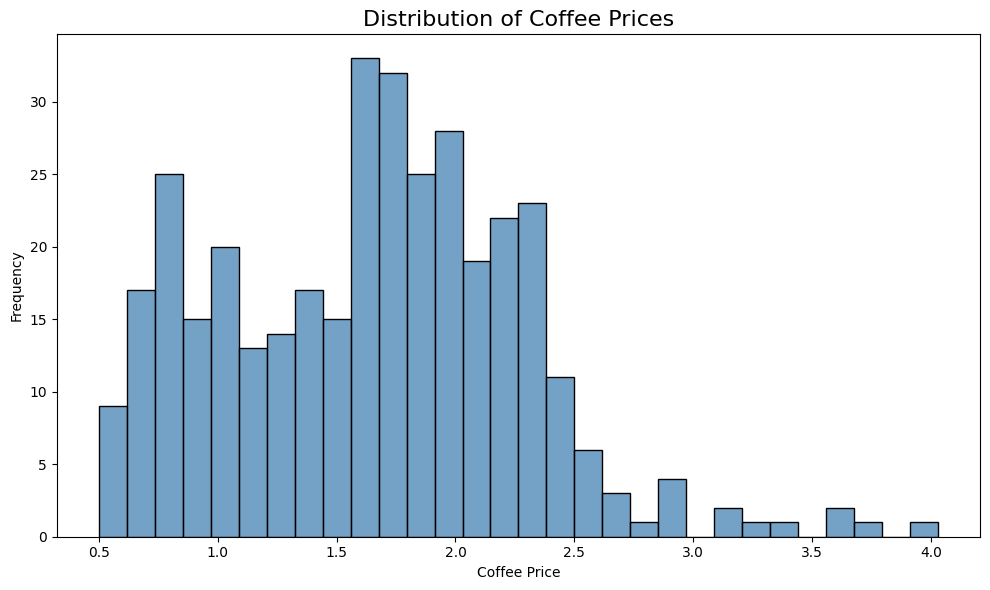

In [99]:
# histogram for coffee prices
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Coffee', bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Coffee Prices', fontsize=16)
plt.xlabel('Coffee Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Historically typical prices for **coffee** is around 1$ - 2$

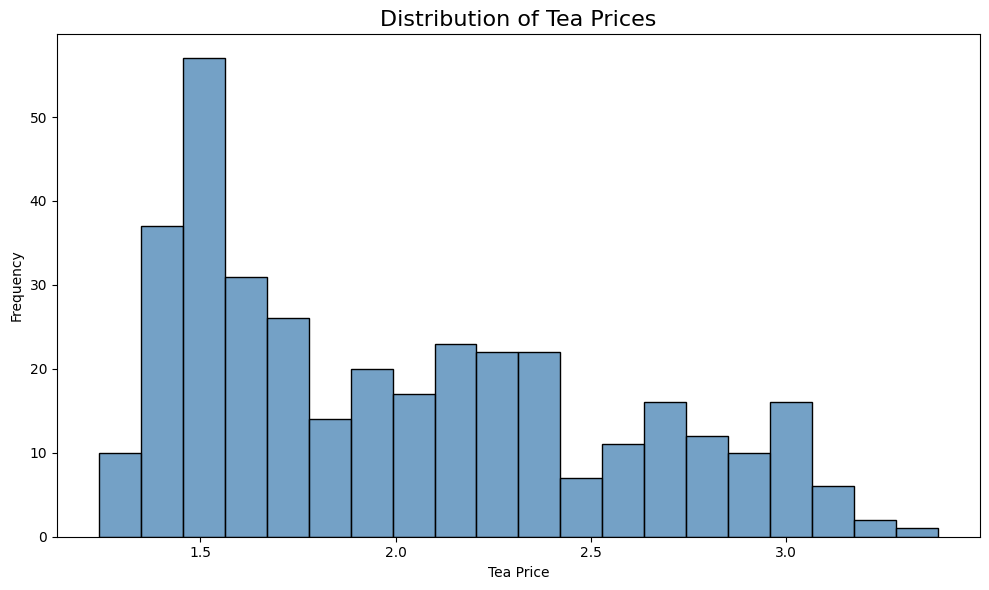

In [100]:
# histogram for tea prices
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Tea', bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Tea Prices', fontsize=16)
plt.xlabel('Tea Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Historically typical prices for **tea** is around 1.5$ - 2.5$